<a href="https://colab.research.google.com/github/Bishalsingh153/Gold-Price-Prediction-Model/blob/main/gold_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

Data collection and processing


In [ ]:
#loading the csv file to a pandas Dataframe
gold_data=pd.read_csv('/content/gld_price_data.csv')

In [ ]:
#print first 5 rows in the Dataframe
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [ ]:
#last 5 rows of the Dataframe
gold_data.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [ ]:
#number of rows and columns
gold_data.shape

(2290, 6)

In [ ]:
#getting some basic information about the data
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [ ]:
#checking the number of missing values
gold_data.isnull().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


In [ ]:
#getting the statisticals measures of the data
gold_data.describe()


,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


Correlation:
1. Positive co-relation
2. Negative co-relation


In [ ]:
correlation=gold_data.corr(numeric_only=True)

<Axes: >

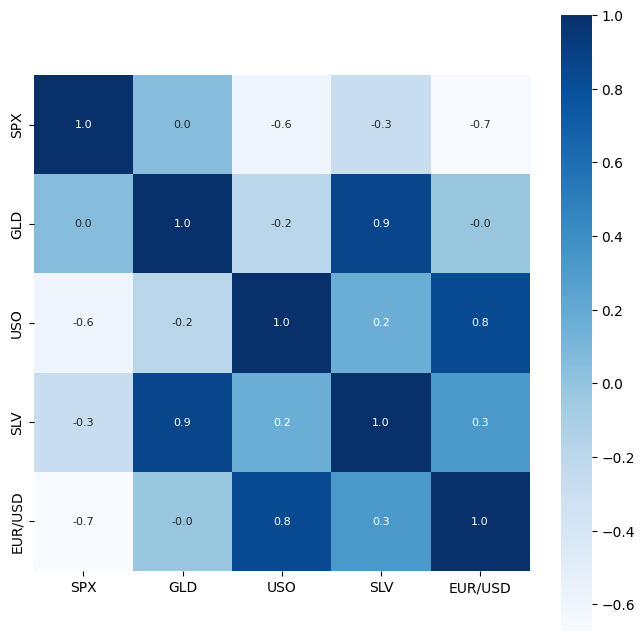

In [ ]:
#Constructing a heat map to understand the correlation
plt.figure(figsize=(8,8))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')

In [ ]:
#Correlation values of Gold
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


/tmp/ipython-input-2053568876.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gold_data['GLD'],color='green')


<Axes: xlabel='GLD', ylabel='Density'>

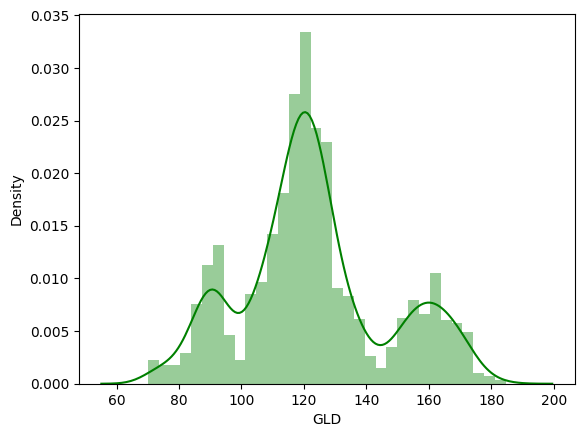

In [ ]:
#Checking the distribution of the GLD Price
sns.distplot(gold_data['GLD'],color='green')

Splitting the features and targets


In [ ]:
X= gold_data.drop(['Date','GLD'],axis=1)
Y=gold_data['GLD']

In [ ]:
print(X)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


In [ ]:
print(Y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


Splitting into training data and test data

In [ ]:
X_train, X_test, Y_train, Y_test =train_test_split(X,Y, test_size=0.2,random_state=2)

Model Training :
Random Forest Regressor

In [ ]:
regressor=RandomForestRegressor(n_estimators=100)

In [ ]:
#training the model
regressor.fit(X_train, Y_train)


RandomForestRegressor()

Model Evaluation

In [ ]:
#Prediction on test data
test_data_prediction=regressor.predict(X_test)

In [ ]:
print(test_data_prediction)

[168.63869949  81.74329996 115.89760008 127.41540079 120.79560144
 154.78599773 150.5428991  126.17460062 117.56629881 125.99700078
 116.53400107 172.25090119 141.35169821 168.01409877 115.12989998
 117.5087003  138.62250297 170.2141013  159.48520285 159.96129949
 155.13040046 125.19280044 176.27720026 157.39650316 125.17590053
  93.67069978  77.35419999 120.58710006 119.024599   167.50870009
  88.36160083 125.1521996   91.14960067 117.51970024 121.14899916
 136.70510079 115.54370098 115.02950082 146.44389909 107.21180092
 104.22090253  87.15339777 126.44520047 118.03740012 154.07589896
 119.59729997 108.51559983 108.04319839  93.09970035 126.99859824
  75.04080038 113.51139906 121.13120009 111.25969926 118.69199893
 120.36289952 159.21310111 169.05510087 146.97799664  85.9359988
  94.38440049  86.77359903  90.73000042 118.92220094 126.47220107
 127.55540003 170.16970024 122.23519941 117.2717987   98.65580009
 168.57940188 143.31789799 132.35060239 121.17450225 120.77909926
 119.615700

In [ ]:
#R squared error
error_score=metrics.r2_score(Y_test, test_data_prediction)

In [ ]:
print("R squared error : ",error_score)

R squared error :  0.9892533574010126


Compare the actual values and predicted values in a plot

In [ ]:
Y_test=list(Y_test)

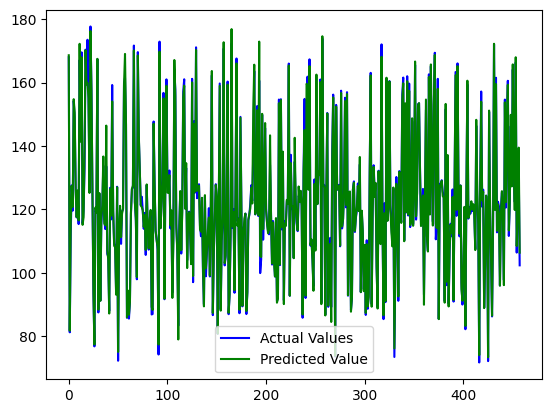

In [ ]:
plt.plot(Y_test, color='blue', label='Actual Values')
plt.plot(test_data_prediction, color='green', label='Predicted Value')
plt.title=("Actual Price VS Predicted Price")
plt.xlabel=('Number of values')
plt.ylabel=('Gold Price')
plt.legend()
plt.show()